# Notebook 2 - Fake News Classification Models and Evaluation

### By: FNF - Fake News Fighter

## **Context of the Notebook 2:**

This notebook builds on the data preparation from Notebook 1 and focuses on feature engineering and model training for fake news classification. Here, we transform the cleaned news articles into numerical features using tokenization, TF-IDF, we do not separately do the stop words remover as enlish stop words were already removed in notebook 1 during preprocessing of datasets. We then use these features to train different machine learning models, such as Logistic regression, Naive Bayes, Decision tree and Random forest. Next, we look at confusion matrix and metrix such as recall, accuracy, precision and f1. The goal is to find out which model works best at identifying fake news, using the features we created from the text data.

## **Environment Setup**

We would like to start with initialising Spark environment by specifying the full path to the Spark installation,enabling us to use PySpark in our notebook. Additionally, we added the exception handling with try/except block to ensure that any errors during initialization are caught and handled in timely manner, as the path might differ depending on the user's environment.

In [1]:
# Importing the findspark module 
import findspark

try:
    # Initializing via the full spark path
    findspark.init("/usr/local/spark/")
    
except Exception as e:
    print(f"Could not initialize Spark environment: {e}")
    print("Please check your Spark installation path.")

As the next step, we initialize a local PySpark environment with a SparkSession named "FakeNewsClassification" and allocate 2 GB executor memory. As well, we prepare both SparkContext and SQLContext for distributed data processing.

In [2]:
# Importing the SparkSession and SQLContent modules
from pyspark.sql import SparkSession
from pyspark.sql import SQLContext

#Next, we are building the spark session, also including the possible exception handling 
try:
    spark = SparkSession.builder \
   .master("local[*]") \
   .appName("FakeNewsClassification") \
   .config("spark.executor.memory", "2g") \
   .getOrCreate()
except Exception as e:
    print("Spark session could not be created:", e)
    raise

# Geting the underlying SparkContext from the SparkSession
sc = spark.sparkContext

# Initializing SQLContext for working with structured data using SQL-like queries for our analysis and preprocessing
sqlContext = SQLContext(sc)

# Setup: Packages, Functions, and Modules

Now, we will import all, used in the context of this notebook 2, modules and functions. 

In [3]:
from pyspark.ml.feature import Tokenizer #tokenizer
from pyspark.ml.feature import HashingTF, IDF # vectorizer
from pyspark.sql.functions import concat_ws, col # to concatinate cols
from pyspark.sql.types import FloatType, DoubleType #types
from pyspark.ml.classification import LogisticRegression #Logistic regression - 1st model
from pyspark.ml.classification import NaiveBayes #Naïve Bayes - 2nd model
from pyspark.ml.classification import DecisionTreeClassifier #Decision Tree - 3rd model
from pyspark.ml.classification import RandomForestClassifier # Random Forest - final/ensemble model

In [4]:
# Evaluation and pipeline
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.mllib.evaluation import MulticlassMetrics 
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.ml import Pipeline
import pyspark.sql.functions as F
import matplotlib.pyplot as plt #visualisation

In [5]:
#tunning and cross-validation
from pyspark.ml.tuning import ParamGridBuilder
from pyspark.ml.tuning import CrossValidator

## Data Loading

First of all, we are loading the processed main ISOT dataset, as well as evaluation WELFake dataset from previous notebook 1, to further train/test and evaluate several classification models, specifically we plan to do Logistic Regression, Naïve Bayes, Classification Tree and Random Forest.

In [6]:
# Loading the data, also including the possible exception handling with the reading path
try:
    main_df = spark.read.csv("./data/processed_df.csv", header=True, inferSchema=True, multiLine=True, escape='"', quote='"')
except Exception as e:
    print("Error loading Fake.csv:", e)

In [7]:
# Loading the data, also including the possible exception handling with the reading path
try:
    evaluation_df = spark.read.csv("./data/processed_eval_df.csv", header=True, inferSchema=True, multiLine=True, escape='"', quote='"')
except Exception as e:
    print("Error loading Fake.csv:", e)

Now, we will briefly have a look at the data to see if the processed in the Notebook 1 datasets loaded as expected.

In [8]:
# Inspecting the data
main_df.show(5, truncate = 50)

+--------------------------------------------------+-----+
|                                              text|label|
+--------------------------------------------------+-----+
|president month leave office stage presidency w...|  1.0|
|year old german man admit court monday sell wea...|  0.0|
|split vote iowa caucus race hillary clinton ber...|  1.0|
|fbi director james comey defend handle democrat...|  0.0|
|top democrat house representative say friday co...|  0.0|
+--------------------------------------------------+-----+
only showing top 5 rows



In [9]:
#Inspecting the data
evaluation_df.show(5, truncate = 50)

+--------------------------------------------------+-----+
|                                              text|label|
+--------------------------------------------------+-----+
|white house say tuesday bill senate pass allow ...|  0.0|
|lithuania government lose majority parliament s...|  0.0|
|charlotte line wave ballot last month force vot...|  0.0|
|attorney represent illegal alien arrest allege ...|  1.0|
|trump administration outline tuesday dismantle ...|  0.0|
+--------------------------------------------------+-----+
only showing top 5 rows



Now, we can start with building of pipeline to train and test our models.

## Pipeline building

With the first step in the pipeline, we convert each news article's text from a single string sentence into a list of individual words (tokens). This tokenization is essential for further text processing, such as feature extraction or embedding, because most NLP models require input as sequences of words rather than raw sentences. 

In [10]:
# convert sentences to list of words
tokenizer = Tokenizer(inputCol="text", outputCol="words")

Next, we apply  the Hashing Term Frequency (HashingTF) transformation to convert the list of words (tokens) into a fixed-length numerical feature vector that represents the frequency of each term in our text. It maps tokens to indices in the feature vector using a hash function, enabling scalable and efficient feature extraction for our machine learning models. 

We don't do stop words remover as we already done this in our preprocessing.

In [11]:
# Calculate term frequency in each article
hashingTF = HashingTF(inputCol=tokenizer.getOutputCol(), outputCol="raw_features")

In the nearly final before model step, we aply the Inverse Document Frequency (IDF) transformation to rescale the raw term frequency vectors. It down-weights terms that appear frequently across many documents and up-weights terms that are more unique to specific documents. This helps the model focus on more informative words for classification by creating the final TF-IDF feature vectors.

In [12]:
# Inverse document frequency
idf = IDF(inputCol="raw_features", outputCol="features")

Finally, we split the main dataset into training and test sets using a 80-20 ratio to ensure that the model is trained on a majority of the data and then evaluated on unseen data. The randomSplit function with a fixed seed ensures reproducibility of the split. We then print the number of records in each set to verify the split.

In [13]:
splits = main_df.randomSplit([0.8, 0.2], seed = 12) #setting seed to keep the result reproducable
train_df = splits[0]
test_df = splits[1]

#Checking the splits
print("Training Dataset Count: " + str(train_df.count()))
print("Test Dataset Count: " + str(test_df.count()))

Training Dataset Count: 34959
Test Dataset Count: 8926


We will also quickly look at the label distribution to make sure the classes in our training data are fairly balanced.

In [14]:
#grouping by label and counting
train_df.groupBy('label').count().show()

+-----+-----+
|label|count|
+-----+-----+
|  0.0|16908|
|  1.0|18051|
+-----+-----+



We can see that difference between the two classes is about 1,143 samples, which is roughly a 6.3% difference relative to the smaller class, so we can consider the training dataset relatively balanced.

## Logistic Regression 

As our first model, we initialize a Logistic Regression model specifying the input features column and label column. 

In [15]:
# logistic model object
lr = LogisticRegression(
    featuresCol='features',
    labelCol='label'       
)

Now, we constructed a pipeline to prevent data leakage that includes tokenization, feature extraction using HashingTF and IDF, followed by logistic regression for classification.

In [16]:
pipeline = Pipeline(stages=[tokenizer, hashingTF, idf, lr])

As the next step, we used the pipeline to train the model on the training data and then tested it on the test data.  It also helps keep everything organized and prevents any data leakage from happening.


In [17]:
# train model with default parameters
lrModel = pipeline.fit(train_df)

# get predictions for test set
predictions = lrModel.transform(test_df)

Now, we want to check the  text, final predictions, and the label for the first 10 rows. The truncate=50 is used to shorten the text display so the output stays readable.

In [18]:
predictions.select("text", 'prediction','label').show(10, truncate = 50)

+--------------------------------------------------+----------+-----+
|                                              text|prediction|label|
+--------------------------------------------------+----------+-----+
|aardvark kill meerkat miss believe dead blaze p...|       1.0|  0.0|
|abc host george stephanopoulos sat interview mo...|       1.0|  1.0|
|abdul razak ali artan somalian refugee come cit...|       1.0|  1.0|
|abortion become legal procedure accord supreme ...|       1.0|  1.0|
|absent parent cashin mcdonald teen shot chicago...|       1.0|  1.0|
|absent parent cashin mcdonald teen shot chicago...|       1.0|  1.0|
|academy motion picture arts science come seriou...|       1.0|  1.0|
|accident good king obama administration continu...|       1.0|  1.0|
|accident president obama name vanita gupta act ...|       1.0|  1.0|
|accord associated press friday president trump ...|       1.0|  1.0|
+--------------------------------------------------+----------+-----+
only showing top 10 

As, we can see model performs quite good on the text data from the same source based on the preliminary check of predictions. Now, we will also have a look at confusion matrix as well as recall, accuracy, precision and f1 scores.

In [19]:
# Groupping by actual label and prediction, then counting
conf_matrix = predictions.groupBy('label', 'prediction').count().orderBy('label', 'prediction')
conf_matrix.show()

+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|  0.0|       0.0| 4037|
|  0.0|       1.0|  265|
|  1.0|       0.0|  108|
|  1.0|       1.0| 4516|
+-----+----------+-----+



In our classification task, fake news is labeled as 1 and true news as 0, with the primary goal of detecting fake news (label 1). Examining the prediction results on the test set from the ISOT dataset, the logistic regression model correctly identified 4,037 true news articles as true (True Negatives, TN) and 4,516 fake news articles as fake (True Positives, TP). However, it misclassified 265 true news articles as fake (False Positives, FP) and 108 fake news articles as true (False Negatives, FN).

Based on this confusion matrix, we can calculate and interpret key metrics of interest, such as recall, which measures the model's ability to find all positive instances, all fake news.

In [20]:
acc_evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
print("Accuracy:", acc_evaluator.evaluate(predictions))

Accuracy: 0.9582119650459332


The model achieved an accuracy of 95.82% in detecting fake news (where label 1 indicates fake). This means it correctly identified about 96 out of every 100 news articles as either fake (1) or real (0).

In [21]:
prec_evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="precisionByLabel", metricLabel=1.0)
print("Precision (Fake):", prec_evaluator.evaluate(predictions))

Precision (Fake): 0.9445722652164819


Precision for Fake News (label 1) of 94.46% means that when the model predicts an article is fake, it is correct about 94.46% of the time. In other words, almost all the news labeled as fake by the model truly are fake.

In [22]:
recall_evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="recallByLabel", metricLabel=1.0)
print("Recall (Fake):", recall_evaluator.evaluate(predictions))

Recall (Fake): 0.976643598615917


Recall for Fake News (label 1) of 97.66% means that the model successfully identified about 98% of all the actual fake news articles in the dataset. In other words, it caught most of the fake news, minimizing the number of fake articles that slip through as real.

In [23]:
precision = prec_evaluator.evaluate(predictions)
recall = recall_evaluator.evaluate(predictions)

# Calculating F1 score manually
f1 = 2 * (precision * recall) / (precision + recall)

print(f"F1 Score (Fake news):  {f1:.4f}")

F1 Score (Fake news):  0.9603


The F1 Score for Fake News of 96.03% shows that model balances both accurately identifying fake news when it predicts it (precision) and successfully capturing most of the actual fake news articles (recall). A high F1 score like this indicates strong overall performance in detecting fake news. However, it's important to note that these results may be somewhat optimistic, as the model was evaluated on data from the same dataset it was trained on. Now, we are also going to look at ROC-AUC.

In [24]:
evaluator = BinaryClassificationEvaluator(
    labelCol="label",
    rawPredictionCol="rawPrediction", 
    metricName="areaUnderROC"
)
auc = evaluator.evaluate(predictions)
print(f"AUC: {auc:.4f}")

AUC: 0.9883


The model’s AUC of 0.9883 shows it is highly effective at separating fake news from real news, with near-perfect ability to rank fake news higher than real news across all thresholds, but again it’s important to note that this high AUC may be partly due to the model being evaluated on data from the same dataset it was trained on. Therefore, we will now have a look how model will perform on the unseed data.

### Model performance on the evaluation dataset

Now, we will check the performance of our model on the evaluation dataset, loaded after preprocessing from notebook 1.

In [25]:
# Appling the trained logistic regression model to the evaluation dataset to generate predictions
eval_predictions = lrModel.transform(evaluation_df)

Now, we want to check the text, final predictions, and the label for the first 10 rows. This helps us quickly see how good the model is in its predictions and compare them with the actual labels. The truncate=50 is used to shorten the text display so the output stays readable.

In [26]:
eval_predictions.select("text", 'prediction', 'label').show(10, truncate = 50)

+--------------------------------------------------+----------+-----+
|                                              text|prediction|label|
+--------------------------------------------------+----------+-----+
|white house say tuesday bill senate pass allow ...|       0.0|  0.0|
|lithuania government lose majority parliament s...|       0.0|  0.0|
|charlotte line wave ballot last month force vot...|       1.0|  0.0|
|attorney represent illegal alien arrest allege ...|       1.0|  1.0|
|trump administration outline tuesday dismantle ...|       0.0|  0.0|
|european union leader appeal unity last ditch e...|       0.0|  0.0|
|representative facebook twitter google ask appe...|       0.0|  0.0|
|clarified protesting united state challenge pla...|       1.0|  1.0|
|president trump crack joke national prayer brea...|       1.0|  0.0|
|update hillary clinton investigation fbi indict...|       1.0|  1.0|
+--------------------------------------------------+----------+-----+
only showing top 10 

As, we can see model performs quite good on the text data from the evaluation source based on the preliminary check of predictions. Now, we will also have a look at confusion matrix as well as recall, accuracy, precision and f1 scores.

In [27]:
# Groupping by actual label and prediction, then counting
conf_matrix = eval_predictions.groupBy('label', 'prediction').count().orderBy('label', 'prediction')
conf_matrix.show()

+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|  0.0|       0.0|25478|
|  0.0|       1.0| 9539|
|  1.0|       0.0| 1575|
|  1.0|       1.0|33499|
+-----+----------+-----+



On the evaluation dataset, the model correctly identified 25,478 real news articles as true (True Negatives, TN) and 33,499 fake news articles as fake (True Positives, TP). However, it also misclassified 9,539 real news articles as fake (False Positives, FP) and 1,575 fake news articles as real (False Negatives, FN).

In [28]:
print("Accuracy:", acc_evaluator.evaluate(eval_predictions))

Accuracy: 0.841434706310368


Now, on the evaluation dataset, model achieved an accuracy of 84.14% on the evaluation dataset. This means it correctly classified approximately 84 out of every 100 news articles as either real or fake. While this indicates generally strong performance, it also suggests room for improvement, especially considering the impact of false positives and false negatives in fake news detection.

In [29]:
print("Precision (Fake):", prec_evaluator.evaluate(eval_predictions))

Precision (Fake): 0.7783586597890236


The precision for fake news (label 1) is 77.84%, meaning that when the model predicts an article is fake, it's correct about 78% of the time. In other words, out of all articles the model labeled as fake, roughly 22% were actually real — indicating a moderate rate of false alarms. 

In [30]:
print("Recall (Fake):", recall_evaluator.evaluate(eval_predictions))

Recall (Fake): 0.9550949421223699


The recall for fake news (label 1) is 95.51%, meaning the model successfully identified about 96 out of every 100 actual fake news articles. 

In [31]:
precision = prec_evaluator.evaluate(eval_predictions)
recall = recall_evaluator.evaluate(eval_predictions)

# Calculating F1 score manually
f1 = 2 * (precision * recall) / (precision + recall)

print(f"F1 Score (Fake news):  {f1:.4f}")

F1 Score (Fake news):  0.8577


The F1 Score for fake news is 85.77%, reflects a balanced performance: the model is fairly good at both correctly identifying fake news (high recall) and ensuring that its fake news predictions are accurate (reasonable precision). An F1 score at this level suggests quite good in our case, but improvable, overall effectiveness in fake news detection.


Now, we are also going to look at ROC-AUC.

In [32]:
evaluator = BinaryClassificationEvaluator(
    labelCol="label",
    rawPredictionCol="rawPrediction", 
    metricName="areaUnderROC"
)
auc = evaluator.evaluate(eval_predictions)
print(f"AUC: {auc:.4f}")

AUC: 0.8697


The model’s AUC of 0.8697 indicates that it performs well in distinguishing fake news from real news, with a strong ability to rank fake news articles higher than real ones across all classification thresholds, but slightly lower then the AUC score on the test set (0.9883), but this is due to the fact that the test set comes from the same dataset as train set. This means the model is more familiar with the patterns in the test set, leading to better performance. In contrast, the evaluation set may have different characteristics or more varied examples, making the classification task harder and resulting in a lower AUC, but at the same time providing us with more objective result.

### Cross-validation and choosing of best model

Now, to improve our model’s performance and select the best hyperparameters, we decided to perform cross-validation using a parameter grid. We defined a grid over the regularization parameter (regParam) and the elastic net mixing parameter (elasticNetParam) to explore different combinations. Using 2-fold cross-validation (for efficiency reasons), we trained multiple models and selected the best one based on our evaluation metric. Finally, we applied this best model to the evaluation dataset to analyze its performance using a confusion matrix.

In [33]:
paramGrid = (
    ParamGridBuilder()  # setting parameters to test during cross-validation
    .addGrid(lr.regParam, [0.01, 0.1])
    .addGrid(lr.elasticNetParam, [0.0, 0.5])
    .build()
)

crossval = CrossValidator( # full ML pipeline to be trained and validated for our logistic regression
    estimator=pipeline,
    estimatorParamMaps=paramGrid,
    evaluator=evaluator,
    numFolds=2,
    parallelism=2
)

We are going to fit the cross-validation process on the training dataset to evaluate different hyperparameter combinations. After training, we select the best-performing model from the cross-validation results to use for further evaluation and prediction.

In [34]:
# Fitting cross validator (using our training data)
cvModel = crossval.fit(train_df)

# Use best model
bestModel = cvModel.bestModel

To inspect the details of the best logistic regression model selected by cross-validation, we extract the final model stage from the pipeline. Then, we print out all its parameters and their values to understand the specific settings used in the best model.

In [35]:
lrModel = bestModel.stages[-1]  #to extract only model to check the parameters
for param, value in lrModel.extractParamMap().items():
    print(param.name, "->", value)

aggregationDepth -> 2
elasticNetParam -> 0.5
family -> auto
featuresCol -> features
fitIntercept -> True
labelCol -> label
maxIter -> 100
predictionCol -> prediction
probabilityCol -> probability
rawPredictionCol -> rawPrediction
regParam -> 0.01
standardization -> True
threshold -> 0.5
tol -> 1e-06


We found through cross-validation that the best logistic regression model uses elastic net regularization with a balanced mix of L1 and L2 penalties (elasticNetParam = 0.5) and a regularization strength of 0.01. The model fits an intercept and standardizes features for better training stability. It runs up to 100 iterations with a strict convergence tolerance. Predictions are based on a 0.5 probability threshold to classify outcomes. Now, we gonna check the ROC-AUC score for our model as well as confusion matrix, and other metrics of interest for us.


In [36]:
best_predictions = bestModel.transform(evaluation_df) #getting predictions for evaluation dataset

In [37]:
evaluator = BinaryClassificationEvaluator(
    labelCol="label",
    rawPredictionCol="rawPrediction", 
    metricName="areaUnderROC"
)
auc = evaluator.evaluate(best_predictions)
print(f"AUC: {auc:.4f}")

AUC: 0.8859


The best model achieved an excellent test AUC of 0.8859, indicating it very accurately distinguishes between the classes.

To further evaluate the performance of the best model on the evaluation dataset, we grouped the predictions by their actual labels and predicted labels, then counted the number of instances in each group. This allowed us to build and visualize the confusion matrix, which shows how well the model classified each class, and further count the metrics like recall, precision, accuracy, f1.

In [38]:
# Groupping by actual label and prediction, then counting
conf_matrix = best_predictions.groupBy('label', 'prediction').count().orderBy('label', 'prediction')
conf_matrix.show()

+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|  0.0|       0.0|26572|
|  0.0|       1.0| 8445|
|  1.0|       0.0| 2986|
|  1.0|       1.0|32088|
+-----+----------+-----+



On the evaluation dataset, the model correctly identified 26,572 instances of class 0 as real news (True Negatives, TN) and 32,088 instances of class 1 as fake news (True Positives, TP). However, it also misclassified 8,445 real news articles as fake (False Positives, FP) and 2,986 fake news articles as real (False Negatives, FN).


In [39]:
print("Accuracy:", acc_evaluator.evaluate(best_predictions))

Accuracy: 0.8369120143813044


The cross-validated logistic model achieved an accuracy of 83.69% on the evaluation dataset, meaning it correctly classified approximately 84 out of every 100 news articles as either real or fake. While this indicates solid overall performance, it also highlights to us that some misclassifications still occur — which is important in a sensitive task like fake news detection.

In [40]:
print("Precision (Fake):", prec_evaluator.evaluate(best_predictions))

Precision (Fake): 0.7916512471319666


The model achieved a precision of 79.17% for detecting fake news. This means that when the model predicted an article as fake, it was correct about 79 times out of 100. A lower precision can indicats to us that there is a higher number of false positives, where real news is mistakenly flagged as fake — which can be problematic in maintaining trust, but at the same time this metric got better comparing to the previous model on the evaluation dataset, where precision was 77.84%.

In [41]:
#Storing for later on comparison and visualisation
logistic_recall = recall_evaluator.evaluate(best_predictions)

print("Recall (Fake):", logistic_recall)

Recall (Fake): 0.914865712493585


Now we can also observe that model achieved a recall of 91.49% for fake news, meaning it successfully identified over 91% of all actual fake news articles in the dataset. This high recall indicates strong effectiveness in catching fake news, with relatively few false negatives — which is especially valuable when the priority is to minimize undetected misinformation.

In [42]:
precision = prec_evaluator.evaluate(best_predictions)
recall = recall_evaluator.evaluate(best_predictions)

# Calculating F1 score manually
f1 = 2 * (precision * recall) / (precision + recall)

print(f"F1 Score (Fake news):  {f1:.4f}")

F1 Score (Fake news):  0.8488


The model achieved an F1 Score of 84.88% for detecting fake news suggesting the model maintains a good balance between correctly flagging fake news and avoiding incorrect classifications.

#### Comparison with model on evaluation dataset before tunning

The logistic model trained with cross-validation achieved an accuracy of 83.69%, which is very close to the 84.14% accuracy observed in the initial model prediction on the evaluation dataset without cross-validation. Its recall of 91.49% demonstrates a strong ability to identify positive cases, although it is slightly lower than the 95.51% recall seen in the results of the enitial logistic regression model on evaluation dataset. This suggests that the cross-validated model catches most positives but misses a few more than the initial model.

However, the cross-validated model exhibits a higher precision of 79.17% compared to 77.84% in the untuned model, indicating it produces fewer false positive errors relative to its positive predictions. The F1 scores for both models are quite similar, 84.88% for the cross-validated model and 86.97% for the untuned model—showing that both maintain a good balance between precision and recall.

Overall, the cross-validated model reliable performance, effectively balancing detection and false alarms thanks to hyperparameter tuning. In contrast, the initial model without cross-validation appears more heavily tuned toward maximizing recall, prioritizing detection of as many positive cases as possible, but with a slightly higher false positive rate. Also, when evaluating the model on the test split, it showed very strong performance metrics, often even better than on the evaluation set. However, this high performance we believe is likely due to some degree of overfitting because the test data originates from the same source and distribution as the training data.

Additionally, the best model selected through cross-validation achieved a higher test AUC of approximately 0.8859, compared to the initial model’s AUC of 0.8697. This improvement indicates that the cross-validated model has a better overall ability to distinguish between positive and negative classes, reflecting more effective and reliable classification performance. So for further choosing of model and comparison between different models like logistic, naive bayes, decision tree and random forest we will use this final cross-validated model.

## Naïve Bayes 

As our second model, we initialized a Naive Bayes classifier specifying the input features, label, prediction, and probability columns to perform text classification.


In [43]:
nb = NaiveBayes(featuresCol='features', labelCol='label', predictionCol="prediction", probabilityCol="probability")

Now, we constructed a pipeline to prevent data leakage that includes tokenization, feature extraction using HashingTF and IDF, followed by naive bayes for classification.

In [44]:
pipeline = Pipeline(stages=[tokenizer, hashingTF, idf, nb])

As the next step, we used the pipeline to train the model on the training data and then tested it on the test data. It also helps keep everything organized and prevents any data leakage from happening.

In [45]:
# Training
feature_model = pipeline.fit(train_df)

# Prediction
predictions_nb = feature_model.transform(test_df)

Now, we want to check the text, final prediction, and the label for the first 10 rows. This helps us quickly see how good the model is in its predictions and compare them with the actual labels. The truncate=50 is used to shorten the text display so the output stays readable.

In [46]:
predictions_nb.select("text", 'prediction', 'label').show(10, truncate = 50)

+--------------------------------------------------+----------+-----+
|                                              text|prediction|label|
+--------------------------------------------------+----------+-----+
|aardvark kill meerkat miss believe dead blaze p...|       1.0|  0.0|
|abc host george stephanopoulos sat interview mo...|       1.0|  1.0|
|abdul razak ali artan somalian refugee come cit...|       1.0|  1.0|
|abortion become legal procedure accord supreme ...|       1.0|  1.0|
|absent parent cashin mcdonald teen shot chicago...|       1.0|  1.0|
|absent parent cashin mcdonald teen shot chicago...|       1.0|  1.0|
|academy motion picture arts science come seriou...|       1.0|  1.0|
|accident good king obama administration continu...|       1.0|  1.0|
|accident president obama name vanita gupta act ...|       1.0|  1.0|
|accord associated press friday president trump ...|       1.0|  1.0|
+--------------------------------------------------+----------+-----+
only showing top 10 

As, we can see model performs quite good on the text data from the same source based on the preliminary check of predictions. Now, we will also have a look at confusion matrix as well as recall, accuracy, precision and f1 scores.

In [47]:
# Groupping by actual label and prediction, then counting
conf_matrix = predictions_nb.groupBy('label', 'prediction').count().orderBy('label', 'prediction')
conf_matrix.show()

+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|  0.0|       0.0| 3931|
|  0.0|       1.0|  371|
|  1.0|       0.0|  220|
|  1.0|       1.0| 4404|
+-----+----------+-----+



On the test split, the model correctly identified 3,931 instances of true news (label 0) as true (True Negatives, TN) and 4,404 instances of fake news (label 1) as fake (True Positives, TP). However, it misclassified 371 true news instances as fake (False Positives, FP) and 220 fake news instances as true (False Negatives, FN).

In [48]:
print("Accuracy:", acc_evaluator.evaluate(predictions_nb))

Accuracy: 0.9337889312121891


The model achieved 93.38% accuracy on the test set, correctly classifying most true and fake news articles, with relatively few misclassifications.

In [49]:
print("Precision (Fake):", prec_evaluator.evaluate(predictions_nb))

Precision (Fake): 0.922303664921466


The model’s precision for detecting fake news is about 92.23%, meaning that when it predicts an article as fake, it is correct over 92% of the time.

In [50]:
print("Recall (Fake):", recall_evaluator.evaluate(predictions_nb))

Recall (Fake): 0.9524221453287197


The model’s recall for fake news is approximately 95.24%, indicating it successfully identifies over 95% of all actual fake news articles.

In [51]:
precision = prec_evaluator.evaluate(predictions_nb)
recall = recall_evaluator.evaluate(predictions_nb)

# Calculating F1 score manually
f1 = 2 * (precision * recall) / (precision + recall)

print(f"F1 Score (Fake news):  {f1:.4f}")

F1 Score (Fake news):  0.9371


The model’s F1 score for fake news detection is 93.71%, reflecting a strong balance between precision and recall.

### Model performance on the evaluation dataset

Now, we will check the performance of our model on the evaluation dataset.

In [52]:
eval_predictions_nb = feature_model.transform(evaluation_df)

Now, we want to check the text,  final prediction, and the label for the first 10 rows. This helps us quickly see how good the model is in its predictions and compare them with the actual labels. The truncate=50 is used to shorten the text display so the output stays readable.

In [53]:
eval_predictions_nb.select("text", 'prediction', 'label').show(10, truncate = 50)

+--------------------------------------------------+----------+-----+
|                                              text|prediction|label|
+--------------------------------------------------+----------+-----+
|white house say tuesday bill senate pass allow ...|       0.0|  0.0|
|lithuania government lose majority parliament s...|       0.0|  0.0|
|charlotte line wave ballot last month force vot...|       1.0|  0.0|
|attorney represent illegal alien arrest allege ...|       1.0|  1.0|
|trump administration outline tuesday dismantle ...|       0.0|  0.0|
|european union leader appeal unity last ditch e...|       0.0|  0.0|
|representative facebook twitter google ask appe...|       0.0|  0.0|
|clarified protesting united state challenge pla...|       1.0|  1.0|
|president trump crack joke national prayer brea...|       1.0|  0.0|
|update hillary clinton investigation fbi indict...|       1.0|  1.0|
+--------------------------------------------------+----------+-----+
only showing top 10 

As, we can see model performs quite good on the text data from the evaluation source based on the preliminary check of predictions. Now, we will also have a look at confusion matrix as well as recall, accuracy, precision and f1 scores.

In [54]:
# Groupping by actual label and prediction, then counting
conf_matrix = eval_predictions_nb.groupBy('label', 'prediction').count().orderBy('label', 'prediction')
conf_matrix.show()

+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|  0.0|       0.0|24574|
|  0.0|       1.0|10443|
|  1.0|       0.0| 3243|
|  1.0|       1.0|31831|
+-----+----------+-----+



On the evaluation dataset, the model correctly identified 24,574 true news articles (label 0) as true (True Negatives, TN) and 31,831 fake news articles (label 1) as fake (True Positives, TP). However, it misclassified 10,443 true news articles as fake (False Positives, FP) and 3,243 fake news articles as true (False Negatives, FN).

In [55]:
print("Accuracy:", acc_evaluator.evaluate(eval_predictions_nb))

Accuracy: 0.8047395528669872


The model achieved an accuracy of approximately 80.47% on the evaluation dataset, meaning it correctly classified about 80 out of every 100 news articles as either true or fake.

In [56]:
print("Precision (Fake):", prec_evaluator.evaluate(eval_predictions_nb))

Precision (Fake): 0.7529687278232483


The model’s precision for detecting fake news is about 75.30%, meaning that when it predicts an article as fake, it is correct roughly 3/4 of the time.

In [57]:
naive_recall = recall_evaluator.evaluate(eval_predictions_nb) #for later visualisation

print("Recall (Fake):", naive_recall)

Recall (Fake): 0.9075383474938701


The model’s recall for fake news detection is about 90.75%, meaning it correctly identifies roughly 91% of all actual fake news articles.

In [58]:
precision = prec_evaluator.evaluate(eval_predictions_nb)
recall = recall_evaluator.evaluate(eval_predictions_nb)

# Calculating F1 score manually
f1 = 2 * (precision * recall) / (precision + recall)

print(f"F1 Score (Fake news):  {f1:.4f}")

F1 Score (Fake news):  0.8231


The model’s F1 score for fake news detection is 82.31%, indicating a good balance between precision and recall in identifying fake news.

#### Comparison between Naive Bayes model performance on test data split and evaluation data split

The model evaluated on the test split shows notably better performance metrics, higher accuracy (93.38%), precision (92.23%), recall (95.24%), and F1 score (93.71%) compared to the model evaluated on the evaluation dataset. It makes fewer misclassifications and appears to generalize well within that data.

However, we believe this strong performance on the test split is likely misleading. Since the test split comes from the same source and distribution as the training data, the model may have overfitted, essentially learning patterns too specific to that dataset. As a result, it might be overgeneralizing on this familiar data, performing unrealistically well.

In contrast, the evaluation dataset likely contains more varied or unseen examples, providing a more realistic assessment of the model’s ability to generalize. Therefore, despite the lower metrics, the evaluation dataset results probably reflect the true predictive power of the model more accurately.

## Decision Tree

As our third model, we initialized a Decision Tree classifier specifying also maxDepth = 5, and limiting features to 10000 for hashingTF to avoid overfitting.

In [59]:
hashingTF = HashingTF(inputCol=tokenizer.getOutputCol(), outputCol="raw_features", numFeatures = 10000)

# Defining the Decision Tree model
dt = DecisionTreeClassifier(labelCol="label", featuresCol="features", maxDepth=5)

Now, we constructed a pipeline to prevent data leakage that includes tokenization, feature extraction using HashingTF and IDF, followed by decision tree for classification.

In [60]:
# Define the pipeline
pipeline = Pipeline(stages=[tokenizer, hashingTF, idf, dt])

As the next step, we used the pipeline to train the model on the training data and then tested it on the test data.

In [61]:
# Train the pipeline on the training data
tree_model = pipeline.fit(train_df)

# Apply to the test data
predictions_tree = tree_model.transform(test_df)

Now, we want to check the text, probabilities, final prediction, and the label for the first 10 rows. This helps us quickly see how good the model is in its predictions and compare them with the actual labels. The truncate=50 is used to shorten the text display so the output stays readable.

In [62]:
predictions_tree.select("text", "probability", 'prediction', 'label').show(10, truncate = 50)

+--------------------------------------------------+----------------------------------------+----------+-----+
|                                              text|                             probability|prediction|label|
+--------------------------------------------------+----------------------------------------+----------+-----+
|aardvark kill meerkat miss believe dead blaze p...|[0.8106706187476843,0.18932938125231566]|       0.0|  0.0|
|abc host george stephanopoulos sat interview mo...| [0.12025316455696203,0.879746835443038]|       1.0|  1.0|
|abdul razak ali artan somalian refugee come cit...|[0.10602798708288483,0.8939720129171151]|       1.0|  1.0|
|abortion become legal procedure accord supreme ...| [0.0114625051788427,0.9885374948211573]|       1.0|  1.0|
|absent parent cashin mcdonald teen shot chicago...|[0.8106706187476843,0.18932938125231566]|       0.0|  1.0|
|absent parent cashin mcdonald teen shot chicago...|[0.8106706187476843,0.18932938125231566]|       0.0|  1.0|
|

As, we can see model performs quite good on the text data from the evaluation source based on the preliminary check of predictions. Now, we will also have a look at confusion matrix as well as recall, accuracy, precision and f1 scores.

In [63]:
# Groupping by actual label and prediction, then counting
conf_matrix = predictions_tree.groupBy('label', 'prediction').count().orderBy('label', 'prediction')
conf_matrix.show()

+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|  0.0|       0.0| 4076|
|  0.0|       1.0|  226|
|  1.0|       0.0| 1158|
|  1.0|       1.0| 3466|
+-----+----------+-----+



On the test split, the decision tree model correctly classified 4,076 true news articles (label 0) as true (True Negatives, TN) and 3,466 fake news articles (label 1) as fake (True Positives, TP). However, it misclassified 226 true news articles as fake (False Positives, FP) and 1,158 fake news articles as true (False Negatives, FN).

In [64]:
print("Accuracy:", acc_evaluator.evaluate(predictions_tree))

Accuracy: 0.8449473448353125


We can see that decision tree model achieved an accuracy of about 84.5%, showing solid performance in distinguishing between true and fake news. While it correctly classified a majority of cases, it still made some errors, particularly misclassifying a notable number of fake news articles as true. 

In [65]:
print("Precision (Fake):", prec_evaluator.evaluate(predictions_tree))

Precision (Fake): 0.9387865655471289


The decision tree model’s precision for detecting fake news is approximately 93.88%, indicating that when it predicts an article as fake, it is correct nearly 94% of the time.

In [66]:
print("Recall (Fake):", recall_evaluator.evaluate(predictions_tree))

Recall (Fake): 0.7495674740484429


The decision tree model’s recall for fake news is about 74.96%, meaning it correctly identifies roughly 75% of all actual fake news articles.

In [67]:
precision = prec_evaluator.evaluate(predictions_tree)
recall = recall_evaluator.evaluate(predictions_tree)

# Calculating F1 score manually
f1 = 2 * (precision * recall) / (precision + recall)

print(f"F1 Score (Fake news):  {f1:.4f}")

F1 Score (Fake news):  0.8336


The decision tree model’s F1 score for fake news detection is 83.36%, indicating a good balance between precision and recall in identifying fake news.

### Model performance on the evaluation dataset

Now, we will check the performance of our model on the evaluation dataset.

In [68]:
eval_predictions_tree = tree_model.transform(evaluation_df)

Now, we want to check the text, probabilities, final prediction, and the label for the first 10 rows. This helps us quickly see how good the model is in its predictions and compare them with the actual labels. The truncate=50 is used to shorten the text display so the output stays readable.

In [69]:
eval_predictions_tree.select("text", "probability", "prediction", "label").show(10, truncate = 50)

+--------------------------------------------------+----------------------------------------+----------+-----+
|                                              text|                             probability|prediction|label|
+--------------------------------------------------+----------------------------------------+----------+-----+
|white house say tuesday bill senate pass allow ...| [0.5248175182481751,0.4751824817518248]|       0.0|  0.0|
|lithuania government lose majority parliament s...|[0.8106706187476843,0.18932938125231566]|       0.0|  0.0|
|charlotte line wave ballot last month force vot...|[0.8106706187476843,0.18932938125231566]|       0.0|  0.0|
|attorney represent illegal alien arrest allege ...|[0.8106706187476843,0.18932938125231566]|       0.0|  1.0|
|trump administration outline tuesday dismantle ...|[0.8106706187476843,0.18932938125231566]|       0.0|  0.0|
|european union leader appeal unity last ditch e...|[0.8106706187476843,0.18932938125231566]|       0.0|  0.0|
|

As, we can see model performs relatively good on the text data from the evaluation source based on the preliminary check of predictions. Now, we will also have a look at confusion matrix as well as recall, accuracy, precision and f1 scores.

In [70]:
# Groupping by actual label and prediction, then counting
conf_matrix = eval_predictions_tree.groupBy('label', 'prediction').count().orderBy('label', 'prediction')
conf_matrix.show()

+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|  0.0|       0.0|28897|
|  0.0|       1.0| 6120|
|  1.0|       0.0|10376|
|  1.0|       1.0|24698|
+-----+----------+-----+



On the evaluation dataset, the decision tree model correctly identified 28,897 instances of true news (label 0) as true (True Negatives, TN) and 24,698 instances of fake news (label 1) as fake (True Positives, TP). However, it misclassified 6,120 true news articles as fake (False Positives, FP) and 10,376 fake news articles as true (False Negatives, FN).

In [71]:
print("Accuracy:", acc_evaluator.evaluate(eval_predictions_tree))

Accuracy: 0.7646488136850665


The decision tree model achieved an accuracy of approximately 76.46%, meaning it correctly classified about 76 out of every 100 news articles as either true or fake on the evaluation dataset.

In [72]:
print("Precision (Fake):", prec_evaluator.evaluate(eval_predictions_tree))

Precision (Fake): 0.8014147576091895


The decision tree model’s precision for detecting fake news is about 80.14%, which means that when it predicts an article as fake, it is correct roughly 80% of the time

In [73]:
tree_recall = recall_evaluator.evaluate(eval_predictions_tree)

print("Recall (Fake):", tree_recall)

Recall (Fake): 0.7041683298169584


The model’s recall for fake news detection is approximately 70.42%, indicating it correctly identifies about 70% of all actual fake news articles.

In [74]:
precision = prec_evaluator.evaluate(eval_predictions_tree)
recall = recall_evaluator.evaluate(eval_predictions_tree)

# Calculating F1 score manually
f1 = 2 * (precision * recall) / (precision + recall)

print(f"F1 Score (Fake news):  {f1:.4f}")

F1 Score (Fake news):  0.7497


The model’s F1 score for fake news detection is 74.97%, showing a moderate balance between precision and recall in identifying fake news.

#### Comparison between decision tree model performance on test data split and evaluation data split

On the test split, the decision tree model performed better, achieving an accuracy of about 84.5%, with high precision (93.88%) and moderate recall (74.96%). This improved performance is likely because the model was tested on data very similar to or from the same distribution as its training set, meaning it “knows” this data well.

However, on the evaluation split, the model’s accuracy dropped to around 76.5%, with lower precision (80.14%) and recall (70.42%). This suggests the evaluation data is more diverse or different from the training data, making it harder for the model to generalize and correctly classify news articles. This gap in performance highlights potential overfitting on the test split and the challenge of maintaining accuracy on truly unseen, varied data in our case for correct fake news classififcation.

## Random Forest

Now, for our final model, we initialized a Random Forest classifier by specifying the input feature and label columns, enabling the model to perform text classification based on the extracted text features. To prepare the text data, we applied HashingTF with a fixed number of 10,000 features to reduce dimensionality and avoid memory issues and overfitting.

In [75]:
# Resetting the number of features to avoid memmory related problems, and avoid overfitting
hashingTF = HashingTF(inputCol=tokenizer.getOutputCol(), outputCol="raw_features", numFeatures = 10000)

# Defining the Random Forest moddel
rf = RandomForestClassifier(labelCol="label", featuresCol="features", numTrees=50, maxDepth=10, seed= 12)

Now, we constructed a pipeline to prevent data leakage that includes tokenization, feature extraction using HashingTF and IDF, followed by decision tree for classification.

In [76]:
# Defining the pipeline
pipeline = Pipeline(stages=[tokenizer, hashingTF, idf, rf])

As the next step, we used the pipeline to train the model on the training data and then tested it on the test data. 

In [77]:
# Train the pipeline on the training data
model = pipeline.fit(train_df)

# Apply to the test data
predictions_forest = model.transform(test_df)


Now, we want to check the text, predicted probabilities, final prediction, and the label for the first 10 rows. This helps us quickly see how good the model is in its predictions and compare them with the actual labels. The truncate=50 is used to shorten the text display so the output stays readable.

In [78]:
predictions_forest.select("text", 'probability','prediction', 'label').show(10, truncate = 50)

+--------------------------------------------------+----------------------------------------+----------+-----+
|                                              text|                             probability|prediction|label|
+--------------------------------------------------+----------------------------------------+----------+-----+
|aardvark kill meerkat miss believe dead blaze p...|[0.49954778578498243,0.5004522142150175]|       1.0|  0.0|
|abc host george stephanopoulos sat interview mo...|[0.36420560731776924,0.6357943926822308]|       1.0|  1.0|
|abdul razak ali artan somalian refugee come cit...| [0.4929744561911544,0.5070255438088456]|       1.0|  1.0|
|abortion become legal procedure accord supreme ...| [0.3189809160231547,0.6810190839768453]|       1.0|  1.0|
|absent parent cashin mcdonald teen shot chicago...| [0.3647057711874483,0.6352942288125517]|       1.0|  1.0|
|absent parent cashin mcdonald teen shot chicago...| [0.3647057711874483,0.6352942288125517]|       1.0|  1.0|
|

As we can see, in general predictions are correct, matching the label. Now, we are going to look at confusion matrix, to later on also calculate recall, precision, accuracy and f1.

In [79]:
# Groupping by actual label and prediction, then counting
conf_matrix = predictions_forest.groupBy('label', 'prediction').count().orderBy('label', 'prediction')
conf_matrix.show()

+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|  0.0|       0.0| 4143|
|  0.0|       1.0|  159|
|  1.0|       0.0|  338|
|  1.0|       1.0| 4286|
+-----+----------+-----+



The random forest model correctly identified 4,143 true news articles (label 0) as true (True Negatives, TN) and 4,286 fake news articles (label 1) as fake (True Positives, TP). However, it misclassified 159 true news articles as fake (False Positives, FP) and 338 fake news articles as true (False Negatives, FN). This indicates the model has strong performance in detecting both classes, with relatively fewer false positives and false negatives compared to some other models.

In [80]:
print("Accuracy:", acc_evaluator.evaluate(predictions_forest))

Accuracy: 0.9443199641496751


The random forest model on test split achieved 94.43% accuracy, with strong precision and recall for detecting fake news, indicating reliable and balanced performance.

In [81]:
print("Precision (Fake):", prec_evaluator.evaluate(predictions_forest))

Precision (Fake): 0.9642294713160855


The model’s precision for fake news is about 96.42%, meaning it is very accurate when predicting articles as fake.

In [82]:
print("Recall (Fake):", recall_evaluator.evaluate(predictions_forest))

Recall (Fake): 0.9269031141868512


The random forest model on the test split recall for fake news is approximately 92.7%, showing it successfully identifies most of the actual fake news articles.

In [83]:
precision = prec_evaluator.evaluate(predictions_forest)
recall = recall_evaluator.evaluate(predictions_forest)

# Calculating F1 score manually
f1 = 2 * (precision * recall) / (precision + recall)

print(f"F1 Score (Fake news):  {f1:.4f}")

F1 Score (Fake news):  0.9452


The model’s F1 score for fake news detection is 94.52%, indicating a strong balance between precision and recall.

### Model performance on the evaluation dataset

Now, we will check the performance of our model on the evaluation dataset.

In [84]:
forest_eval_prediction = model.transform(evaluation_df)

Now, we want to check the text, probabilities, final prediction, and the label for the first 10 rows. This helps us quickly see how good the model is in its predictions and compare them with the actual labels. The truncate=50 is used to shorten the text display so the output stays readable

In [85]:
forest_eval_prediction.select("text", 'probability','prediction', 'label').show(10, truncate = 50)

+--------------------------------------------------+----------------------------------------+----------+-----+
|                                              text|                             probability|prediction|label|
+--------------------------------------------------+----------------------------------------+----------+-----+
|white house say tuesday bill senate pass allow ...|[0.5912786488293765,0.40872135117062336]|       0.0|  0.0|
|lithuania government lose majority parliament s...| [0.6945783181589927,0.3054216818410073]|       0.0|  0.0|
|charlotte line wave ballot last month force vot...| [0.4342483805146909,0.5657516194853092]|       1.0|  0.0|
|attorney represent illegal alien arrest allege ...| [0.4709199748504313,0.5290800251495688]|       1.0|  1.0|
|trump administration outline tuesday dismantle ...|  [0.6157117246704461,0.384288275329554]|       0.0|  0.0|
|european union leader appeal unity last ditch e...| [0.6254331245542218,0.3745668754457781]|       0.0|  0.0|
|

In general random forest, show correct predictions. Now, we are going to look at confusion matrix, to later on also calculate recall, precision, accuracy and f1.

In [86]:
# Groupping by actual label and prediction, then counting
conf_matrix = forest_eval_prediction.groupBy('label', 'prediction').count().orderBy('label', 'prediction')
conf_matrix.show()

+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|  0.0|       0.0|25984|
|  0.0|       1.0| 9033|
|  1.0|       0.0| 4320|
|  1.0|       1.0|30754|
+-----+----------+-----+



On the evaluation dataset, the random forest model correctly identified 25,984 true news articles (label 0) as true (True Negatives, TN) and 30,754 fake news articles (label 1) as fake (True Positives, TP). However, it misclassified 9,033 true news articles as fake (False Positives, FP) and 4,320 fake news articles as true (False Negatives, FN). Now, we will also calculate the metrics, like recall, precision, f1 and accuracy.

In [87]:
print("Accuracy:", acc_evaluator.evaluate(forest_eval_prediction))

Accuracy: 0.8094905194675494


The random forest model achieved an accuracy of about 80.9% on the evaluation dataset, indicating it correctly classified roughly 81 out of every 100 news articles as either true or fake.

In [88]:
print("Precision (Fake):", prec_evaluator.evaluate(forest_eval_prediction))

Precision (Fake): 0.7729660441852867


The model’s precision for detecting fake news is approximately 77.29%, meaning that when it predicts an article as fake, it is correct about 3 out of 4 times.

In [89]:
forest_recall = recall_evaluator.evaluate(forest_eval_prediction) #for later visualisation

print("Recall (Fake):", forest_recall)

Recall (Fake): 0.8768318412499287


The model’s recall for fake news detection is about 87.68%, indicating it correctly identifies nearly 87.68% of all actual fake news articles.

In [90]:
precision = prec_evaluator.evaluate(forest_eval_prediction)
recall = recall_evaluator.evaluate(forest_eval_prediction)

# Calculating F1 score manually
f1 = 2 * (precision * recall) / (precision + recall)

print(f"F1 Score (Fake news):  {f1:.4f}")

F1 Score (Fake news):  0.8216


The model’s F1 score for fake news detection is 82.16%, showing a good balance between precision and recall on the evaluation dataset.

#### Comparison between random forest model performance on test data split and evaluation data split

As we can see, random forest model shows noticeably better performance on the test split compared to the evaluation dataset. On the test split, it achieves a high accuracy of 94.43%, with precision and recall for fake news detection at 96.42% and 92.7%, respectively. This results in a strong F1 score of 94.52%. However, this enhanced performance in the same way is likely influenced by the fact that the test split contains data similar or overlapping with the training set, leading to possible overfitting and overgeneralization.

In contrast, on the more diverse evaluation dataset, the model’s accuracy drops to about 80.9%, with precision falling to 77.29% and recall to 87.68%. The F1 score also decreases to 82.16%. This indicates that while the model remains effective, it faces greater challenges generalizing to new, unseen data compared to the test split. Compared to other models, this pattern highlights that random forest can achieve very high accuracy and recall when evaluated on familiar data, but its performance on diverse data is more modest, reflecting a more realistic measure of its true predictive power.

## Comparison of Different Models and Evaluation 

After comparing multiple models for fake news classification, including logistic regression,naive bayes, decision tree, and random forests, we found that logistic regression tend to perform better compared to others, specifically in the area of recall (91.49), on the cross-validation is the best choice for our goal of of catching most of the fake news, as it provides more reliable estimations and are less overfitted on the train data.

Although the random forest and decision tree models showed very high accuracy and precision on the test split, their performance dropped noticeably on the evaluation dataset, which contains more diverse and unseen examples. This suggests that these tree-based models are likely overfitting the training data and struggle to generalize well to new, varied news articles, though as expected Random Forest(recall = 0.8768) outperfomed Decision tree model (recall = 0.7). Naive Bayes model showed quite good performance as its recall was quite high for the evaluation set (90.75% ) but still lower then for logistic regression. However, its lower precision indicates a tendency to produce more false alarms (false positives).

On the other hand, the logistic regression model with cross-validation demonstrated more balanced and consistent performance. It achieved strong accuracy (83.69%) and recall(91.49%) while maintaining a good precision rate, especially on the evaluation dataset. This indicates that logistic regression is better at capturing the essential patterns in the data without overfitting, which is crucial for detecting fake news where new or unseen cases can differ significantly from the training examples.

In summary, while more complex models like random forests might show impressive metrics on familiar data like our test split, we believe logistic regression shows better results in context of our limited project scope of fake news classification. This balance between precision and recall, and its better generalization to unseen data, make logistic regression the best model choice for our fake news classification problem.


#### VIsualisation of the Recall value for the models performance on the evaluation dataset

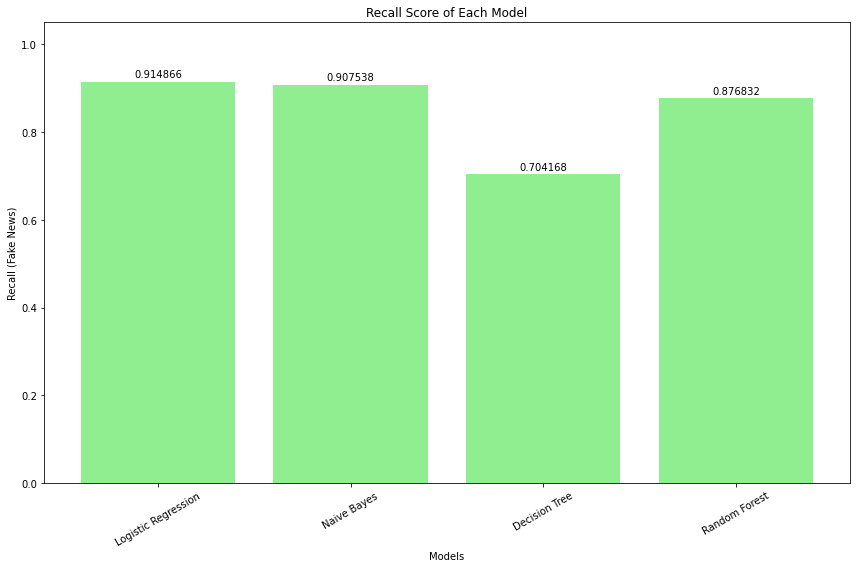

In [91]:
# Model names and recall values
models = ['Logistic Regression', 'Naive Bayes', 'Decision Tree', 'Random Forest']
recalls = [logistic_recall, naive_recall, tree_recall, forest_recall]

def plot_recall_bar():
    plt.figure(figsize=(12, 8)) # to make the plot bigger
    
    x = range(len(models))
    plt.bar(x, recalls, color='lightgreen')
    plt.xlabel('Models')
    plt.ylabel('Recall (Fake News)')
    plt.title('Recall Score of Each Model')
    plt.xticks(ticks=x, labels=models, rotation=30)

    # Annotating each bar with its value
    for i in x:
        plt.text(i, recalls[i] + 0.01, f'{recalls[i]:.6f}', ha='center', fontsize=10)

    plt.ylim(0, 1.05)
    plt.tight_layout()
    plt.show()

plot_recall_bar()